In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("/content/Churn.csv")


In [4]:
print("Shape:", df.shape)
print(df.head())

Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

In [5]:
print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-

In [6]:

print("\nDuplicate Records:")
print(df.duplicated().sum())


Duplicate Records:
0


In [7]:

print("\nTarget Distribution:")
print(df["Churn"].value_counts())


Target Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


# VISUALIZATION 1
# CHURN DISTRIBUTION

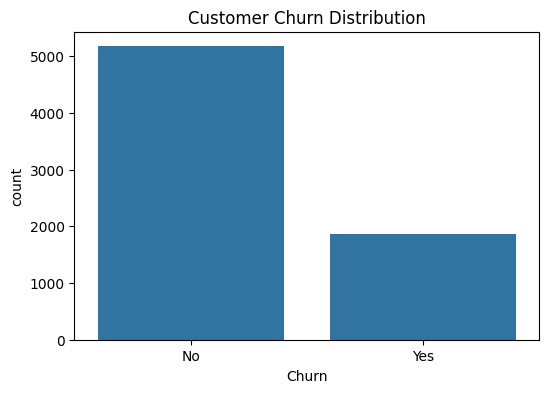

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

# VISUALIZATION 2
# CONTRACT VS CHURN

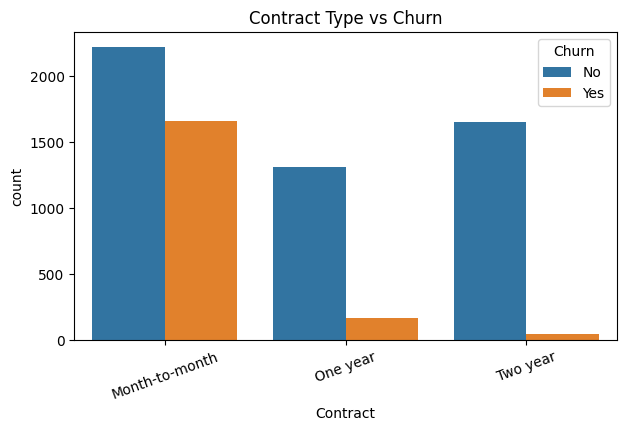

In [9]:
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=20)
plt.show()

# VISUALIZATION 3
# TENURE VS CHURN

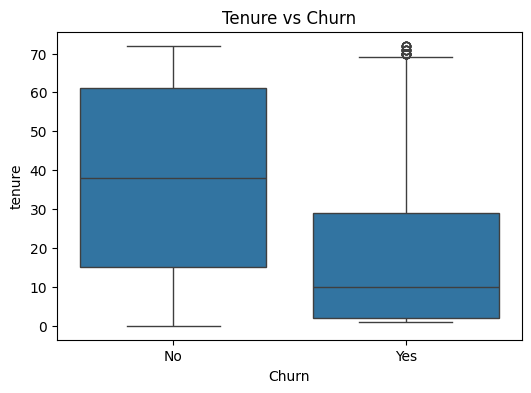

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()


# VISUALIZATION 4
# MONTHLY CHARGES VS CHURN


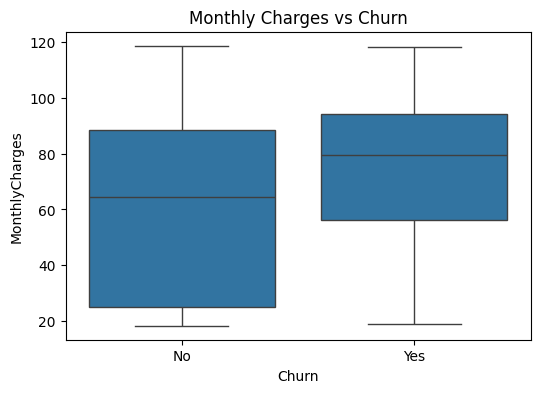

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()



drop customer id


In [ ]:
df.drop("customerID", axis=1, inplace=True)

In [12]:
df = pd.get_dummies(df, drop_first=True)

print("\nEncoded Dataset Shape:", df.shape)


Encoded Dataset Shape: (7043, 13602)


# FEATURES & TARGET

In [13]:
X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

# TRAIN TEST SPLIT

In [14]:
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

X_train Shape: (5634, 13601)
X_test Shape : (1409, 13601)


# FEATURE SCALING


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODEL 1 : LOGISTIC REGRESSION

In [16]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("\n==============================")
print("LOGISTIC REGRESSION RESULTS")
print("==============================")

print("\nAccuracy:")
print(accuracy_score(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))


LOGISTIC REGRESSION RESULTS

Accuracy:
0.7636621717530163

Classification Report:
              precision    recall  f1-score   support

       False       0.77      0.98      0.86      1035
        True       0.73      0.17      0.28       374

    accuracy                           0.76      1409
   macro avg       0.75      0.58      0.57      1409
weighted avg       0.76      0.76      0.71      1409


Confusion Matrix:
[[1011   24]
 [ 309   65]]


# ==========================================================
# MODEL 2 : RANDOM FOREST

In [19]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\n==============================")
print("RANDOM FOREST RESULTS")
print("==============================")

print("\nAccuracy:")
print(accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))


RANDOM FOREST RESULTS

Accuracy:
0.8005677785663591

Classification Report:
              precision    recall  f1-score   support

       False       0.83      0.92      0.87      1035
        True       0.68      0.46      0.55       374

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix:
[[955  80]
 [201 173]]


# MODEL COMPARISON

In [20]:
lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_acc, rf_acc]
})

print("\nModel Comparison")
print(comparison)


Model Comparison
                 Model  Accuracy
0  Logistic Regression  0.763662
1        Random Forest  0.800568


In [21]:
if lr_acc > rf_acc:
    print("\nBest Model : Logistic Regression")
else:
    print("\nBest Model : Random Forest")


Best Model : Random Forest


In [22]:
print("\nFINAL RECOMMENDATIONS")

print("""
1. Identify customers predicted as churn and target them with retention offers.

2. Encourage month-to-month customers to move to annual contracts.

3. Provide loyalty discounts to high-risk customers.

4. Improve customer support and service quality.

5. Deploy the model as an early warning system for the retention team.

6. Monitor high-value customers with higher monthly charges.

7. Use churn predictions to reduce customer attrition and increase profitability.
""")


FINAL RECOMMENDATIONS

1. Identify customers predicted as churn and target them with retention offers.

2. Encourage month-to-month customers to move to annual contracts.

3. Provide loyalty discounts to high-risk customers.

4. Improve customer support and service quality.

5. Deploy the model as an early warning system for the retention team.

6. Monitor high-value customers with higher monthly charges.

7. Use churn predictions to reduce customer attrition and increase profitability.

